<a href="https://colab.research.google.com/github/encoras/Artificial-Intelligence-Group/blob/master/opencv_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Approach to Moving Object tracking

https://www.youtube.com/watch?v=VJKElFaXjt8


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
# Sukuriamas sekiklis (TLD arba CSRT)
tracker = cv2.legacy.TrackerCSRT_create()

#"https://raw.githubusercontent.com/encoras/Introduction-to-OpenCV/master/Camera2.mp4"

inputt = 'https://raw.githubusercontent.com/encoras/Introduction-to-OpenCV/master/Camera2.mp4'

capture = cv2.VideoCapture(inputt)
frame_width = int(capture.get(3))
frame_height = int(capture.get(4))
out = cv2.VideoWriter('Tracker_frame_output.mp4',cv2.VideoWriter_fourcc(*'mp4v'),30, (frame_width,frame_height))

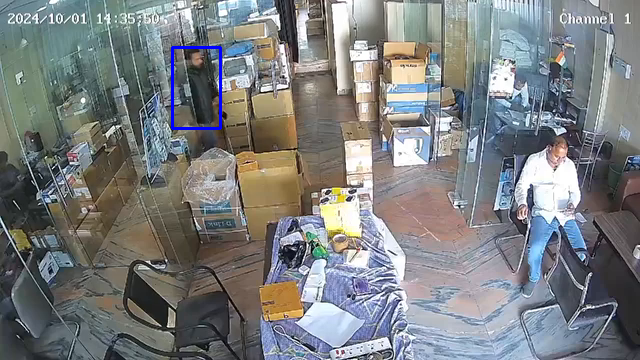

Showing frame #1


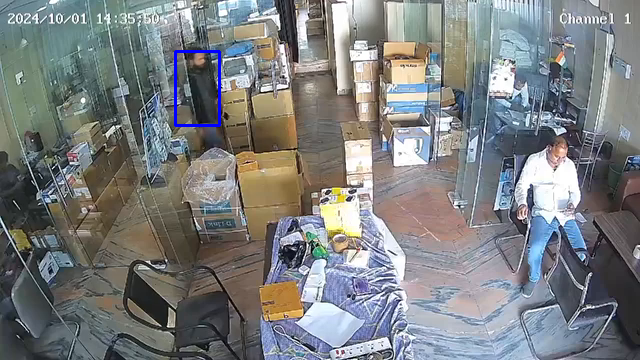

Showing frame #2


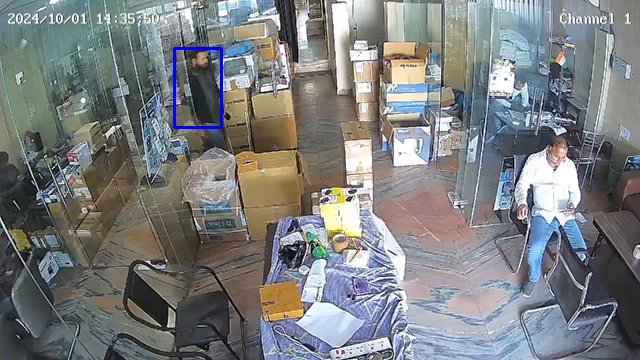

Showing frame #3


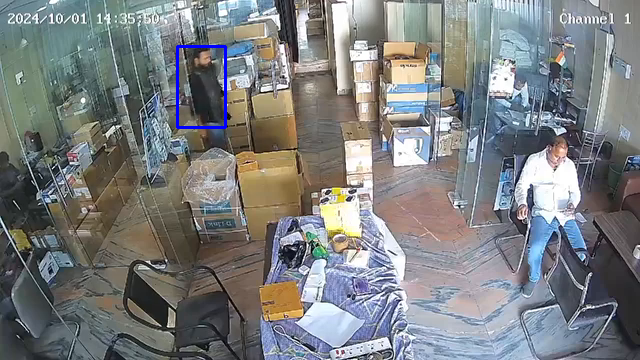

Showing frame #4
End of video / camera error


In [ ]:
ret, frame1 = capture.read()
ret, frame1 = capture.read()
ret, frame1 = capture.read()
ret, frame1 = capture.read()
ret, frame1 = capture.read()
ret, frame1 = capture.read()
ret, frame1 = capture.read()
if not ret:
    print("Cannot read first frame")
    # exit or handle error



frame_count = 0
bbox = (172, 48, 47, 79)
tracker.init(frame1, bbox)
while True:
    ret, frame2 = capture.read()
    if not ret:
        print("End of video / camera error")
        break

    frame_count += 1




    success, bbox = tracker.update(frame2)
    if success:
        # Nubraižome rėmelį aplink sekamą objektą
        p1 = (int(bbox[0]), int(bbox[1]))
        p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
        cv2.rectangle(frame2, p1, p2, (255, 0, 0), 2, 1)

    display_frame = frame2.copy()

    if frame_count < 5:

      cv2_imshow(display_frame)   # Colab
      print(f"Showing frame #{frame_count}")
    # cv2.imshow("Motion", display_frame)   # normal python
    out.write(display_frame)



capture.release()
out.release()